<!-- ## intro to scikit learn lib -->

In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
# heart_disease = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/heart-disease.csv")
heart_disease = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/heart-disease.csv")

heart_disease



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
# except Target , all columns are feature var columns

#create X (features matrix)
X= heart_disease.drop("target",axis=1)
X

#create Y (labels)
y = heart_disease["target"]
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [4]:
#choose a right model and hyperparameters

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100)
#keeping default params
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [5]:
#fit model to training data
from sklearn.model_selection import train_test_split
X_train, X_test ,y_train , y_test = train_test_split(X,y,test_size=0.2) 
clf.fit(X_train , y_train)

#make a prediction 
y_preds = clf.predict(X_test)
y_preds


array([0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1])

In [6]:
y_test

201    0
89     1
262    0
158    1
256    0
      ..
42     1
174    0
33     1
224    0
80     1
Name: target, Length: 61, dtype: int64

In [7]:
# evaluate the model
clf.score(X_train,y_train)

1.0

In [8]:
clf.score(X_test,y_test)


0.819672131147541

In [9]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83        31
           1       0.83      0.80      0.81        30

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [10]:
# confusion_matrix(y_test,y_preds)

In [11]:
accuracy_score(y_test,y_preds)


0.819672131147541

In [12]:
#improve model
#try different amount of n_estimators
np.random.seed(42)

for i in range(10,100,10):
    print(f"trying models with {i} estimators")
    clf= RandomForestClassifier(n_estimators=i).fit(X_train,y_train)
    # clf.fit(X_train,y_train)
    print(f"model accuracy on test set : {clf.score(X_test,y_test)*100:.2f}%")

trying models with 10 estimators
model accuracy on test set : 77.05%
trying models with 20 estimators
model accuracy on test set : 81.97%
trying models with 30 estimators
model accuracy on test set : 81.97%
trying models with 40 estimators
model accuracy on test set : 81.97%
trying models with 50 estimators
model accuracy on test set : 81.97%
trying models with 60 estimators
model accuracy on test set : 83.61%
trying models with 70 estimators
model accuracy on test set : 86.89%
trying models with 80 estimators
model accuracy on test set : 86.89%
trying models with 90 estimators
model accuracy on test set : 78.69%


In [13]:
#save a model and load it
import pickle
pickle.dump(clf,open("randomForestmod1.pkl","wb"))

In [14]:
loaded_model = pickle.load(open("randomForestmod1.pkl","rb"))
loaded_model.score(X_test,y_test)

0.7868852459016393

In [15]:
import sklearn
sklearn.show_versions()


System:
    python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
executable: c:\Users\Sanjay B\anaconda3\python.exe
   machine: Windows-11-10.0.26100-SP0

Python dependencies:
      sklearn: 1.7.1
          pip: 24.2
   setuptools: 75.1.0
        numpy: 2.3.1
        scipy: 1.16.0
       Cython: None
       pandas: 2.3.1
   matplotlib: 3.10.0
       joblib: 1.4.2
threadpoolctl: 3.6.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: openblas
    num_threads: 8
         prefix: libscipy_openblas
       filepath: C:\Users\Sanjay B\anaconda3\Lib\site-packages\numpy.libs\libscipy_openblas64_-860d95b1c38e637ce4509f5fa24fbf2a.dll
        version: 0.3.30
threading_layer: pthreads
   architecture: SkylakeX

       user_api: openmp
   internal_api: openmp
    num_threads: 8
         prefix: vcomp
       filepath: C:\Users\Sanjay B\anaconda3\Lib\site-packages\sklearn\.libs\vcomp140.dll
        version: None

 

In [16]:
## getting data ready to be used with machine learning

'''
split the data into features and labels (X and y)
filling or imputing or disregarding missing values
conveting non-numeric values to numeric called feature encoding

'''

'\nsplit the data into features and labels (X and y)\nfilling or imputing or disregarding missing values\nconveting non-numeric values to numeric called feature encoding\n\n'

In [17]:
heart_disease.head()
X = heart_disease.drop("target",axis=1)
X
y = heart_disease["target"]
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [18]:
# split the data into training and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [19]:
carsales = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/car-sales-extended.csv")
carsales.head()

X = carsales.drop("Price",axis=1)
y= carsales["Price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)


In [63]:
#Building machine learning models
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.8524590163934426

In [23]:
#converting non-numeric columns to numeric
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot',
                                  one_hot,
                                  categorical_features)],
                                  remainder="passthrough")

transformed_x = transformer.fit_transform(X)
df_transformed = pd.DataFrame(transformed_x)
df_transformed

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [66]:
dummies = pd.get_dummies(carsales[['Make',"Colour","Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [68]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)

model = RandomForestRegressor()
model.fit(X_train,y_train)

X_train,X_test,y_train,y_test = train_test_split(transformed_x,y,test_size=0.2)
# transformed_x


ValueError: Found input variables with inconsistent numbers of samples: [950, 303]

In [69]:
model.score(X_test,y_test)


0.5300502155172415

In [70]:
# creating X and y
car_sales_missing = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/car-sales-extended-missing-data.csv")

X = car_sales_missing.drop("Price",axis=1)
y = car_sales_missing["Price"]

In [71]:

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

car_sales_missing = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/car-sales-extended-missing-data.csv")

car_sales_missing.dropna(inplace=True)


X= car_sales_missing.drop("Price",axis=1)
y = car_sales_missing["Price"]

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot',
                                  one_hot,
                                  categorical_features)],
                                  remainder="passthrough")

transformed_x = transformer.fit_transform(car_sales_missing)
df_transformed = pd.DataFrame(transformed_x)
df_transformed
# car_sales_missing.shape


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0,15323.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0,19943.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0,28343.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0,13434.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0,14043.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,163322.0,31666.0
769,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0,32042.0
770,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0,31570.0
771,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0,4001.0


In [72]:
car_sales_missing = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/car-sales-extended-missing-data.csv")
car_sales_missing.isna().sum()

car_sales_missing.dropna(subset=["Price"],inplace=True)
car_sales_missing.isna().sum()


Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [30]:
# split into X and y

car_sales_missing["Price"] = car_sales_missing["Price"].replace('[/$/,]',"",regex=True).astype("int")
car_sales_missing

X = car_sales_missing.drop("Price",axis=1)
y = car_sales_missing["Price"]

In [32]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

#fill categorical with "missing" and numerical values with "mean"

cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant",fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

#define columns

cat_features = ["Make","Colour"]
num_features = ["Odometer (KM)"]
door_features = ["Doors"]

#creating an imputer (something that fills the data)
imputer = ColumnTransformer([
    ("cat_imputer",cat_imputer,cat_features),
    ("num_imputer",num_imputer,num_features),
    ("door_imputer",door_imputer,door_features)
                             ])
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 35431.0, 4.0],
       ['BMW', 'Blue', 192714.0, 5.0],
       ['Honda', 'White', 84714.0, 4.0],
       ...,
       ['Nissan', 'Blue', 66604.0, 4.0],
       ['Honda', 'White', 215883.0, 4.0],
       ['Toyota', 'Blue', 248360.0, 4.0]], shape=(950, 4), dtype=object)

In [33]:
car_sales_filled = pd.DataFrame(filled_X,columns=["Make","Colour","Doors","Odometer (KM)"])
car_sales_filled
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [34]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot',
                                  one_hot,
                                  categorical_features)],
                                  remainder="passthrough")

transformed_x = transformer.fit_transform(car_sales_filled).toarray()
df_transformed = pd.DataFrame(transformed_x)
df_transformed

,0,1,2,3,4,5,6,7,8,9,...,903,904,905,906,907,908,909,910,911,912
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
946,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
947,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
948,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


In [35]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(df_transformed,y,test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train,y_train)
model.score(X_train,y_train)
model.score(X_test,y_test)

-0.044955128011236356

In [36]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(df_transformed,y,test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train,y_train)
model.score(X_train,y_train)
model.score(X_test,y_test)

-0.044955128011236356

In [37]:
from sklearn.datasets import fetch_california_housing
#import ml algo / estimator
from sklearn.linear_model import Ridge

np.random.seed(42)

housing = fetch_california_housing()
#housing = fetch_california_housing(as_frame=True) #imports as dataframe format directly

housing
housing_df = pd.DataFrame(housing.data)


#optional , set columns 
housing_df = pd.DataFrame(housing.data,columns=housing.feature_names)
housing_df["target"] = housing["target"]
# housing_df = housing_df.drop("target",axis=1)
housing_df

X = housing_df.drop("target",axis=1)
y = housing_df["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

#instantiate and fit the model 
model = Ridge()
model.fit(X_train,y_train)
model.score(X_test, y_test)

# X_test.shape,y_test.shape



0.5758549611440127

In [38]:
from sklearn.datasets import fetch_california_housing
#import ml algo / estimator
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

housing = fetch_california_housing()
#housing = fetch_california_housing(as_frame=True) #imports as dataframe format directly

housing
housing_df = pd.DataFrame(housing.data)


#optional , set columns 
housing_df = pd.DataFrame(housing.data,columns=housing.feature_names)
housing_df["target"] = housing["target"]
# housing_df = housing_df.drop("target",axis=1)
housing_df

X = housing_df.drop("target",axis=1)
y = housing_df["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

#instantiate and fit the model 
model = RandomForestRegressor()
model.fit(X_train,y_train)
model.score(X_test, y_test)

# X_test.shape,y_test.shape



0.806652667101436

## classification problem


In [39]:
#using linearSVC - linear support vector classification
from sklearn.svm import LinearSVC

np.random.seed(42)
heart_disease = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/heart-disease.csv")

#split data into X,y

X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

#splitting into training test 

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
model = LinearSVC()
#model = LinearSVC(max_iter=10000)  # Increase max_iter if convergence warning occurs
model.fit(X_train,y_train)
model.score(X_test,y_test)

# heart_disease["target"].value_counts()

0.8688524590163934

In [40]:
## ensemble 

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
heart_disease = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/heart-disease.csv")

#split data into X,y

X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

#splitting into training test 

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train,y_train)
model.score(X_test,y_test)

# heart_disease["target"].value_counts()

0.8524590163934426

In [41]:
## ensemble -- model fitting

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
heart_disease = pd.read_csv("../zero-to-mastery-ml-master/zero-to-mastery-ml-master/data/heart-disease.csv")

#split data into X,y

X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

#splitting into training test 

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
#fitting model
model = RandomForestClassifier()
model.fit(X_train,y_train)
model.score(X_test,y_test)

# heart_disease["target"].value_counts()

0.8524590163934426

In [42]:
print(model.predict(X_test))
# print(model.predict(y_test))


[0 1 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]


In [43]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [44]:
#compare predictions to truth tables to evaluate models
y_preds = model.predict(X_test)
np.mean(y_preds==y_test)

np.float64(0.8524590163934426)

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_preds)

0.8524590163934426

In [46]:
#predict_proba - returns probability of a classification label
model.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [47]:
model.predict(X_test[:5])


array([0, 1, 1, 0, 1])

In [48]:
from sklearn.ensemble import RandomForestRegressor

#split X , y
X = housing_df.drop("target",axis=1)
y = housing_df["target"]

#train test split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestRegressor() #n_estimators =100 by default
model.fit(X_train,y_train)
model.score(X_test,y_test)
y_preds = model.predict(X_test)

In [49]:
y_preds[:10]

array([1.7471   , 1.23883  , 2.3498401, 1.93005  , 1.27568  , 0.94658  ,
       2.03018  , 1.0961002, 3.176421 , 1.62525  ])

In [50]:
np.array(y_test[:10])

array([1.339  , 1.291  , 1.996  , 1.856  , 1.121  , 0.93   , 1.906  ,
       0.733  , 5.00001, 1.403  ])

In [51]:
len(y_preds)
len(y_test)

4128

In [ ]:
#compare predictions to truth
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)

0.32810424590600795

In [ ]:
# using ensemble classifier

from sklearn.ensemble import RandomForestClassifier

#split X , y
X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

#train test split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestClassifier() #n_estimators =100 by default
model.fit(X_train,y_train)
model.score(X_train,y_train)
model.score(X_test,y_test)



0.8524590163934426

In [ ]:
y_preds = model.predict(X_test)
y_preds


array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1])

In [52]:
# using ensemble regressor

from sklearn.ensemble import RandomForestRegressor

#split X , y
X = housing_df.drop("target",axis=1)
y = housing_df["target"]

#train test split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestRegressor(n_estimators=50) #n_estimators =100 by default
model.fit(X_train,y_train)
# model.score(X_train,y_train)
model.score(X_test,y_test)



0.8130997852116184

In [53]:
print(housing_df['target'].value_counts())  # or whatever your target column is
print(housing_df['target'].dtype)

target
5.00001    965
1.37500    122
1.62500    117
1.12500    103
1.87500     93
          ... 
3.52500      1
4.65000      1
4.57500      1
2.61200      1
3.07900      1
Name: count, Length: 3842, dtype: int64
float64


In [73]:
y_test.mean()

np.float64(0.5245901639344263)

In [75]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestRegressor

#split X , y
X = housing_df.drop("target",axis=1)
y = housing_df["target"]

#train test split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestRegressor() #n_estimators =100 by default
model.fit(X_train,y_train)
# model.score(X_train,y_train)
# model.score(X_test,y_test)
cross_val_score(model,X,y,cv=5)



array([0.51574942, 0.70431543, 0.73947117, 0.61872064, 0.68002602])

In [76]:
np.random.seed(42)

model_single_score = model.score(X_test,y_test)

#scoring parameter is set to None by default
#defalut scoring parameter of classifier is mean accuracy
#default scoring parameter of regressor is R^2
model_cross_val_score = np.mean(cross_val_score(model,X,y,cv=5,scoring=None))

model_single_score, model_cross_val_score

(0.806749827280478, np.float64(0.6521550148270838))

In [77]:
np.random.seed(42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
# model_single_score = model.score(X_test,y_test)

X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]
model= RandomForestClassifier()
model_cross_val_score = np.mean(cross_val_score(model,X,y,cv=5,scoring=None))
print(f"heart disease classifier cross validated score : {model_cross_val_score*100:.2f}%")

heart disease classifier cross validated score : 82.48%


In [78]:
np.random.seed(42)

# from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
# model_single_score = model.score(X_test,y_test)
X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]
model=RandomForestClassifier()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
model.fit(X_train,y_train)

y_probs = model.predict_proba(X_test)
y_probs_pos = y_probs[:,1]
y_probs_pos

#cal fpr , tpr , threshold

fpr , tpr , threshold = roc_curve(y_test,y_probs_pos)
fpr , tpr , threshold


(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.06896552,
        0.06896552, 0.10344828, 0.13793103, 0.13793103, 0.17241379,
        0.17241379, 0.27586207, 0.4137931 , 0.48275862, 0.55172414,
        0.65517241, 0.72413793, 0.72413793, 0.82758621, 1.        ]),
 array([0.     , 0.03125, 0.09375, 0.375  , 0.4375 , 0.4375 , 0.46875,
        0.59375, 0.6875 , 0.6875 , 0.71875, 0.75   , 0.75   , 0.875  ,
        0.875  , 0.96875, 0.96875, 0.96875, 0.96875, 0.96875, 0.96875,
        0.96875, 1.     , 1.     , 1.     ]),
 array([ inf, 1.  , 0.99, 0.83, 0.82, 0.8 , 0.78, 0.74, 0.67, 0.66, 0.64,
        0.62, 0.61, 0.53, 0.51, 0.3 , 0.2 , 0.16, 0.14, 0.13, 0.11, 0.07,
        0.06, 0.05, 0.  ]))

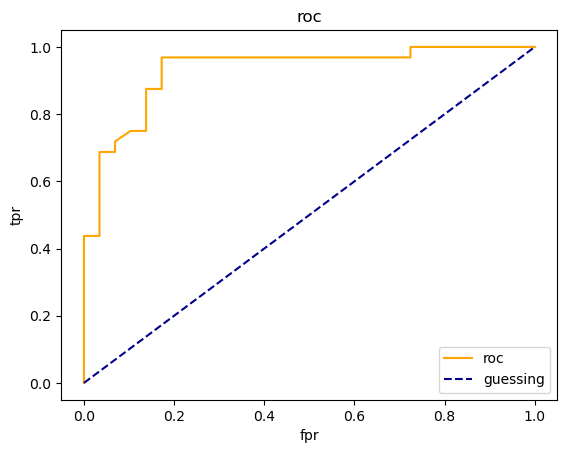

0.9304956896551724


In [79]:
#creating plot function
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


def plot_roc(fpr,tpr):
    plt.plot(fpr,tpr,color="orange",label="roc")
    plt.plot([0,1],[0,1],color="darkblue",label="guessing",linestyle="--")
    plt.xlabel("fpr")
    plt.ylabel("tpr")
    plt.title("roc")
    plt.legend()
    plt.show()
    
plot_roc(fpr,tpr)
print(roc_auc_score(y_test,y_probs_pos))

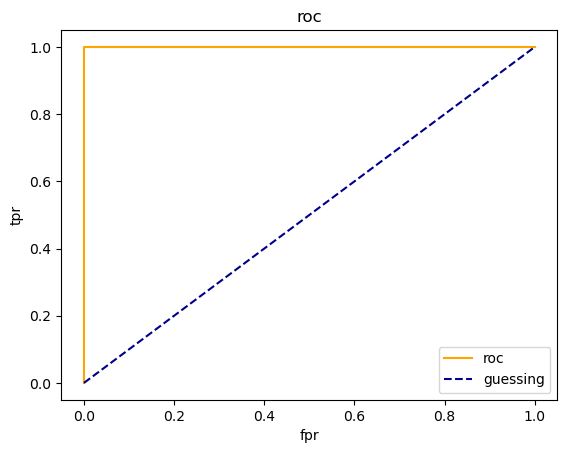

1.0


In [80]:
#plot perfect roc curve and auc score 
fpr,tpr , threshold = roc_curve(y_test,y_test)
plot_roc(fpr,tpr)
print(roc_auc_score(y_test,y_test))


## confusion matrix

In [81]:
from sklearn.metrics import confusion_matrix

y_preds = model.predict(X_test)
cfm = confusion_matrix(y_test,y_preds)

#visualise with pf.crosstab

df = pd.crosstab(y_test,y_preds,rownames=["actual labels"],colnames=["predicted labels"])
df

predicted labels,0,1
actual labels,,
0,24,5
1,4,28


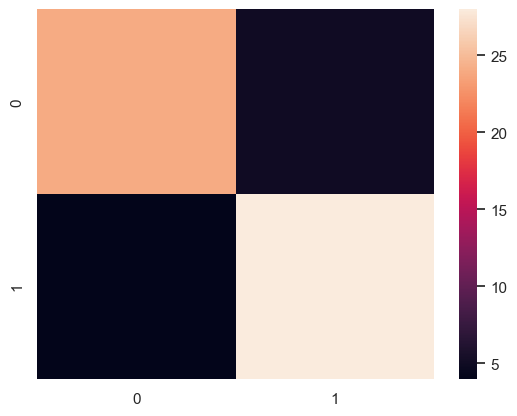

In [82]:
import seaborn as sns
sns.set(font_scale=1)

conf_mat = confusion_matrix(y_test,y_preds)
sns.heatmap(conf_mat)
plt.show()


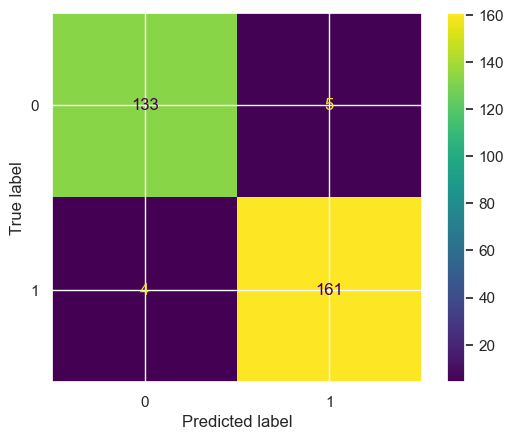

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator=model,X=X, y=y)
plt.show()

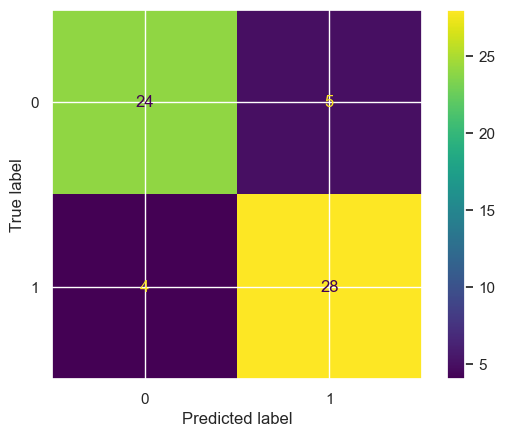

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true=y_test,y_pred=y_preds)
plt.show()